## Let's play around with different binarization methods

modified from `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/DMS_assays/archives/notebooks/binarization_automatic.ipynb` (By Lood in August 2023)


Updated: Elain on May 18 2025

### Goal: Experiment with a few DMS assays to see if it's possible to create an automatic binarization threshold

In PG1, we typically manually inspect the data distribution to decide whether it's bimodal. If so, we choose a binarization threshold. In PG2 (or v1.4), we borrow code from this notebook for
- visualizing all the mutations, ideally colored by one of (synonymous, nonsense, missense, wildtype)
- automatically choosing a binarization cutoff

If the data don't look bimodal, then just use the median, **ALWAYS VISUALIZE**
- if dealing with large datasets, e.g., Megascale or Domainome, visualizing a few is ok


TO-DO:
- bimodality test
- how to use GMM?

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns
from scipy import stats
# Naive GMM without other info
from sklearn.mixture import GaussianMixture


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60) # None

ModuleNotFoundError: No module named 'tqdm'

In [2]:
# Inputs
reference_file = "/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/reference_files/DMS_substitutions_WIP_2023_11_28.csv"  # 2023_08_23 has old binarization thresholds
dms_assays_folder = "/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym/DMS_assays/preprocessed_substitutions/"  # Could also use processed ones

plots_folder = "../raw_data/plot_substitutions/" # change this later

# Outputs
mapping_file_with_thresholds = None
# mapping_file_with_thresholds = "../raw_data/DMS_substitutions_reference_WIP_with_thresholds_2023_08_28.csv"

In [3]:
df_ref = pd.read_csv(reference_file)

include_versions = [1] # ["1", "purgatory", "hold"]  # "hold": Need Nathan's phenotype columns for this
df_new = df_ref[df_ref["ProteinGym_version"].isin(include_versions)].copy()
df_new.head()

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,DMS_number_multiple_mutants,DMS_binarization_cutoff,DMS_binarization_method,first_author,title,year,jo,region_mutated,molecule_name,selection_assay,selection_type,library_construction,replicates,MSA_filename,MSA_start,MSA_end,MSA_len,MSA_bitscore,MSA_theta,MSA_num_seqs,MSA_perc_cov,MSA_num_cov,MSA_N_eff,MSA_Neff_L,MSA_Neff_L_category,MSA_num_significant,MSA_num_significant_L,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,reviewed_by,Comments,Old_DMS_ID,Old_UniProt_ID,Old_target_seq,MSA_comments,pdb_file,ProteinGym_version,raw_mut_offset,coarse_selection_type,coarse_selection_reason
94,PAI1_HUMAN_Huttinger_2021,PAI1_HUMAN_Huttinger_2021.csv,PAI1_HUMAN,Human,Homo sapiens,MQMSPALTCLVLGLALVFGEGSAVHHPPSYVAHLASDFGVRVFQQV...,402,False,5345,5345,0,0.029314,median,Huttinger,Deep mutational scanning of the plasminogen ac...,2021,10.1038/s41598-021-97871-7,24-402,"PAI-1, SERPINE1",PAI-1 inhibition of uPA,phage fitness,ePCR,NaN,PAI1_HUMAN_2023-10-12_b05.a2m,1,402,402,0.5,0.2,52528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PAI1_HUMAN_Huttinger_2021,log2FoldChange,1,mutation,PAI1_HUMAN_theta0.2_2023-10-12_b05.npy,NaN,NaN,NaN,NaN,MQMSTVCLALGLALVFGEASASYLHETRAAELATDFGVKVFKQVAQ...,b04 might be better than b03 and they have the...,PAI1_HUMAN.pdb,1.0,NaN,Activity,NaN
95,HXK4_HUMAN_Gersing_2023_abundance,HXK4_HUMAN_Gersing_2023_abundance.csv,HXK4_HUMAN,Human,Homo sapiens,MLDDRARMEAAKKEKVEQILAEFQLQEEDLKKVMRRMQKEMDRGLR...,465,False,8396,8396,0,0.600000,manual_Lood,Gersing,Characterizing glucokinase variant mechanisms ...,2023,10.1101/2023.05.24.542036,2-465,GCK,abundance,Growth,Oligo-directed mutagenic PCR,"no, but calculated standard errors of abundanc...",HXK4_HUMAN_2023-08-07_b01.a2m,1,465,465,0.1,0.2,24177,0.966,449.0,2626.4,5.849443,Medium,170.0,0.378619,HXK4_HUMAN_Gersing_2022.csv,score,1,mutant,HXK4_HUMAN_theta0.2_2023-08-07_b01.npy,Lood,Possible imputation,NaN,NaN,NaN,NaN,HXK4_HUMAN.pdb,1.0,NaN,Expression,Growth rate engineered to depend on HXK4 abund...
96,PHOT_CHLRE_Chen_2023,PHOT_CHLRE_Chen_2023.csv,PHOT_CHLRE,Eukaryote,Chlamydomonas reinhardtii,AGLRHTFVVADATLPDCPLVYASEGFYAMTGYGPDEVLGHNARFLQ...,118,True,167529,2122,165407,0.631702,median,Chen,Deep Mutational Scanning of an Oxygen-Independ...,2023,10.1021/acssynbio.2c00662,1-118,Phototropin,Fluorescence,FACS,site-saturation mutagenesis; combinatorial met...,"yes, 3 biological, spearman's 0.86-0.89",PHOT_CHLRE_2023-08-07_b02.a2m,1,118,118,0.2,0.2,1627150,0.873,103.0,610128.5,5923.577670,High,232.0,2.252427,sb2c00662_si_001.xlsx,mean,1,mutant,PHOT_CHLRE_theta0.2_2023-08-07_b02.npy,Aaron,Combined singles and multiples by normalising ...,NaN,NaN,NaN,NaN,PHOT_CHLRE.pdb,1.0,NaN,Activity,Measures fluorescence of a fluorescent protein
97,S22A1_HUMAN_Yee_2023_abundance,S22A1_HUMAN_Yee_2023_abundance.csv,S22A1_HUMAN,Human,Homo sapiens,PTVDDILEQVGESGWFQKQAFLILCLLSAAFAPICVGIVFLGFTPD...,553,False,9803,9803,0,-1.000000,manual_Lood,Yee,The full spectrum of OCT1 (SLC22A1) mutations ...,2023,10.1101/2023.06.06.543963,1-549,Oct1,abundance,FACS,site-saturation mutagenesis (DIMPLE),"yes, 3",S22A1_HUMAN_2023-08-07_b02.a2m,1,553,553,0.2,0.2,198790,0.807,446.0,32557.5,72.998879,Medium,485.0,1.087444,543963_file04.xlsx,GFP_score,1,mutant,S22A1_HUMAN_theta0.2_2023-08-07_b02.npy,Aaron TODO,todo: replicate corr.,NaN,NaN,NaN,NaN,S22A1_HUMAN.pdb,1.0,NaN,Expression,Measures protein abundance
98,S22A1_HUMAN_Yee_2023_activity,S22A1_HUMAN_Yee_2023_activity.csv,S22A1_HUMAN,Human,Homo sapiens,PTVDDILEQVGESGWFQKQAFLILCLLSAAFAPICVGIVFLGFTPD...,553,False,10094,10094,0,1.000000,manual,Yee,The full spectrum of OCT1 (SLC22A1) mutations ...,2023,10.1101/2023.06.06.543963,1-549,Oct1,uptake of cytotoxic substrate,Growth,site-saturation mutagenesis (DIMPLE),"yes, 3",S22A1_HUMAN_2023-08-07_b02.a2m,1,553,553,0.2,0.2,198790,0.807,446.0,32557.5,72.9

In [4]:
df_ref["ProteinGym_version"].value_counts()

1.0    123
0.1     94
Name: ProteinGym_version, dtype: int64

In [5]:
# For the rows copied from v0.1 (TODO delete all of _ref before filling in from assays?), copy the ffilled values to _new


In [6]:
assert df_new["DMS_id"].str.contains("SOX17").any()
excluded_nathan_assays = ["I4EPC4_9INFA", "Q2N0S5_9HIV1", "escape", "B3RDS9_9INFA", "Ogden_2019", "W8QFD5_ZIKV"]  # Target_seq issues
excluded_nathan_rows = df_new["DMS_id"].apply(lambda x: any(sub in x for sub in excluded_nathan_assays))
assert excluded_nathan_rows.any()
[dms_assay for dms_assay in df_new[~excluded_nathan_rows]["DMS_filename"] if not os.path.isfile(dms_assays_folder + dms_assay)]

assert all([os.path.isfile(dms_assays_folder + dms_assay) for dms_assay in df_new[~excluded_nathan_rows]["DMS_filename"]])

assert not df_new[excluded_nathan_rows]["DMS_id"].str.contains("SOX17").any()

df_new = df_new[~excluded_nathan_rows]

AssertionError: 

In [ ]:
# Example
# Read first file
example_row = df_new[df_new["DMS_id"] == "SOX17_MOUSE_Veerapandian_2018"].iloc[0]
example_path = dms_assays_folder + example_row["DMS_filename"]
df_example = pd.read_csv(example_path)
print(example_row.DMS_id)
df_example.head()

IndexError: single positional indexer is out-of-bounds

### Below is an example of unimodal distribution, so we just pick the median

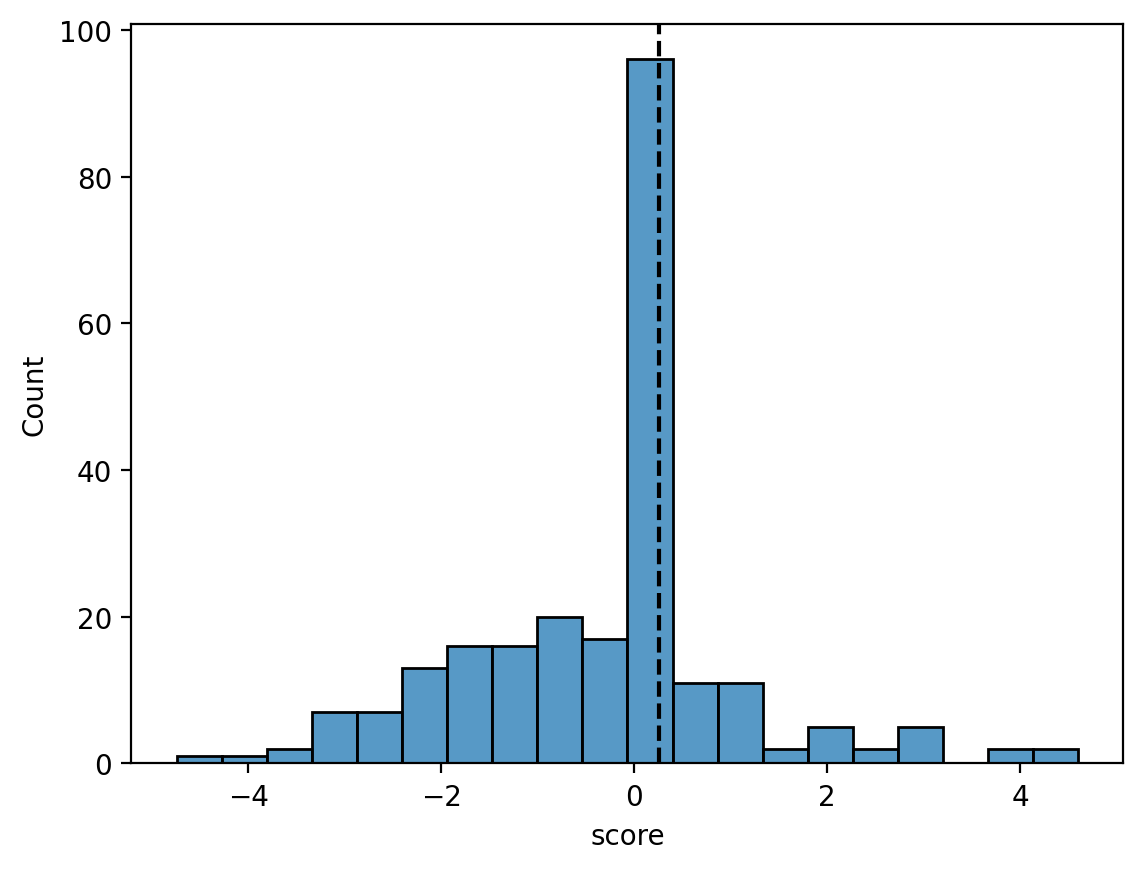

In [ ]:
sns.histplot(df_example, x=example_row["raw_DMS_phenotype_name"])
# Plot median line: Dashed line black
plt.axvline(df_example[example_row["raw_DMS_phenotype_name"]].median(), color="black", linestyle="--")
plt.show()

In [17]:
# Check for synonymous
def get_mutation_class(muts, is_wt_synon=True):
    if all(mut[0] == mut[-1] for mut in muts.split(":")):
        return "synonymous"
    elif "*" in muts or "-" in muts:
        return "nonsense"
    elif "WT" in muts.upper():
        if is_wt_synon:
            return "synonymous"
        else:
            return "wt"
    else:
        return "missense"

# df_example["mutation_class"] = df_example[example_row["raw_DMS_mutant_column"]].apply(get_mutation_class)
# df_example["mutation_class"].value_counts(dropna=False)

In [18]:
sns.histplot(df_example, x=df_new.iloc[0]["raw_DMS_phenotype_name"], hue="mutation_class")
# Plot median line; dashed line black
plt.axvline(df_example[df_new.iloc[0]["raw_DMS_phenotype_name"]].median(), color="black", linestyle="--")
plt.show()

NameError: name 'df_example' is not defined

## Load all DMS files

In [19]:
# Load all the DMS files into memory
assert df_new["raw_DMS_directionality"].isna().sum() == 0
df_new["num_synon"] = None
df_new["num_nonsense"] = None
# To get the keys ordered correctly
from collections import OrderedDict
dfs = OrderedDict()
synon_nonsense_files = []
binarization_thresholds = []

# Iterate through each file, noting number of synonymous and nonsense mutants in the mapping file
for row in tqdm(df_new.itertuples()):
    tmp_df = pd.read_csv(dms_assays_folder + row.DMS_filename)
    tmp_df["mutation_class"] = tmp_df[row.raw_DMS_mutant_column].apply(get_mutation_class)

    # Count number of synonymous and nonsense mutants
    df_new.loc[df_new["DMS_id"] == row.DMS_id, "num_synon"] = (tmp_df["mutation_class"] == "synonymous").sum()
    df_new.loc[df_new["DMS_id"] == row.DMS_id, "num_nonsense"] = (tmp_df["mutation_class"] == "nonsense").sum()
    if tmp_df["mutation_class"].nunique() == 1:
        print(f"No synon/nonsense mutants found in {row.DMS_filename}")
    elif "nonsense" not in tmp_df["mutation_class"].unique():
        print(f"No nonsense mutants found in {row.DMS_filename}")
    else:
        synon_nonsense_files.append(row.DMS_id)
    
    # Rename mutant column
    tmp_df = tmp_df.rename(columns={"mutant": "mutant_old", row.raw_DMS_mutant_column: "mutant", "DMS_score": "DMS_score_old", row.raw_DMS_phenotype_name: "DMS_score"})
    
    # Filter out some NaNs from score column
    if row.DMS_id in ["ARRS_BOVIN_Ostermaier_2014", "A0A3G4RHW3_ATRBE_Wrenbeck_2019", "B3VI55_LIPST_Wrenbeck_2019"]:
        # ARRS_BOVIN "-"
        # A0A3G4RHW3_ATRBE_Wrenbeck_2019 "NS" (not selected)
        # B3VI55_LIPST_Wrenbeck_2019 "NS"
        # Filter out DMS_score == "-" or "NS"
        
        tmp_df = tmp_df[tmp_df["DMS_score"].notna() & ~tmp_df["DMS_score"].apply(lambda s: s == "-" or s == "NS")]
        tmp_df["DMS_score"] = tmp_df["DMS_score"].astype(float)
    
    
    binarization_thresholds.append(tmp_df["DMS_score"].median())  # Note: Binarization threshold applied *before* directionality flip
    
    tmp_df["DMS_score"] = tmp_df["DMS_score"] * float(row.raw_DMS_directionality)
    dfs[row.DMS_id] = tmp_df

df_new["DMS_binarization_cutoff_new"] = binarization_thresholds
df_new["DMS_binarization_method_new"] = "median"
print("Files with synonymous AND nonsense mutations:")
synon_nonsense_files

0it [00:00, ?it/s]

No nonsense mutants found in PAI1_HUMAN_Huttinger_2021.csv
No nonsense mutants found in S22A1_HUMAN_Yee_2023_abundance.csv
No nonsense mutants found in S22A1_HUMAN_Yee_2023_activity.csv
No nonsense mutants found in KCNE1_HUMAN_Muhammad_2023_expression.csv
No nonsense mutants found in KCNE1_HUMAN_Muhammad_2023_function.csv
No nonsense mutants found in Q837P5_ENTFA_Meier_2023.csv
No nonsense mutants found in Q837P4_ENTFA_Meier_2023.csv
No synon/nonsense mutants found in Q53Z42_HUMAN_McShan_2019_expression.csv
No synon/nonsense mutants found in Q53Z42_HUMAN_McShan_2019_binding-TAPBPR.csv
No nonsense mutants found in RPC1_LAMBD_Li_2019_low-expression.csv
No nonsense mutants found in RPC1_LAMBD_Li_2019_high-expression.csv
No nonsense mutants found in B2L11_HUMAN_Dutta_2010_binding-Mcl-1.csv
No synon/nonsense mutants found in HSP82_YEAST_Cote-Hammarlof_2020_growth-H2O2.csv
No nonsense mutants found in F7YBW7_MESOW_Ding_2023.csv
No synon/nonsense mutants found in AICDA_HUMAN_Gajula_2014_3cycl

['HXK4_HUMAN_Gersing_2023_abundance',
 'PHOT_CHLRE_Chen_2023',
 'RNC_ECOLI_Weeks_2023',
 'HEM3_HUMAN_Loggerenberg_2023',
 'OXDA_RHOTO_Vanella_2023_expression',
 'OXDA_RHOTO_Vanella_2023_activity',
 'PRKN_HUMAN_Clausen_2023',
 'DYR_ECOLI_Nguyen_2023',
 'ENVZ_ECOLI_Ghose_2023',
 'MLAC_ECOLI_MacRae_2023',
 'CCR5_HUMAN_Gill_2023',
 'A4_HUMAN_Seuma_2022',
 'SRC_HUMAN_Nguyen_2022',
 'RASK_HUMAN_Weng_2022_abundance',
 'RASK_HUMAN_Weng_2022_binding-DARPin_K55',
 'SRC_HUMAN_Chakraborty_2023_binding-DAS_25uM',
 'MTHR_HUMAN_Weile_2021',
 'RDRP_I33A0_Li_2023',
 'HMDH_HUMAN_Jiang_2019',
 'CAR11_HUMAN_Meitlis_2020_lof',
 'CAR11_HUMAN_Meitlis_2020_gof',
 'CD19_HUMAN_Klesmith_2019_FMC_singles']

### A skewed distribution, but still only take the median

<AxesSubplot: xlabel='DMS_score', ylabel='Count'>

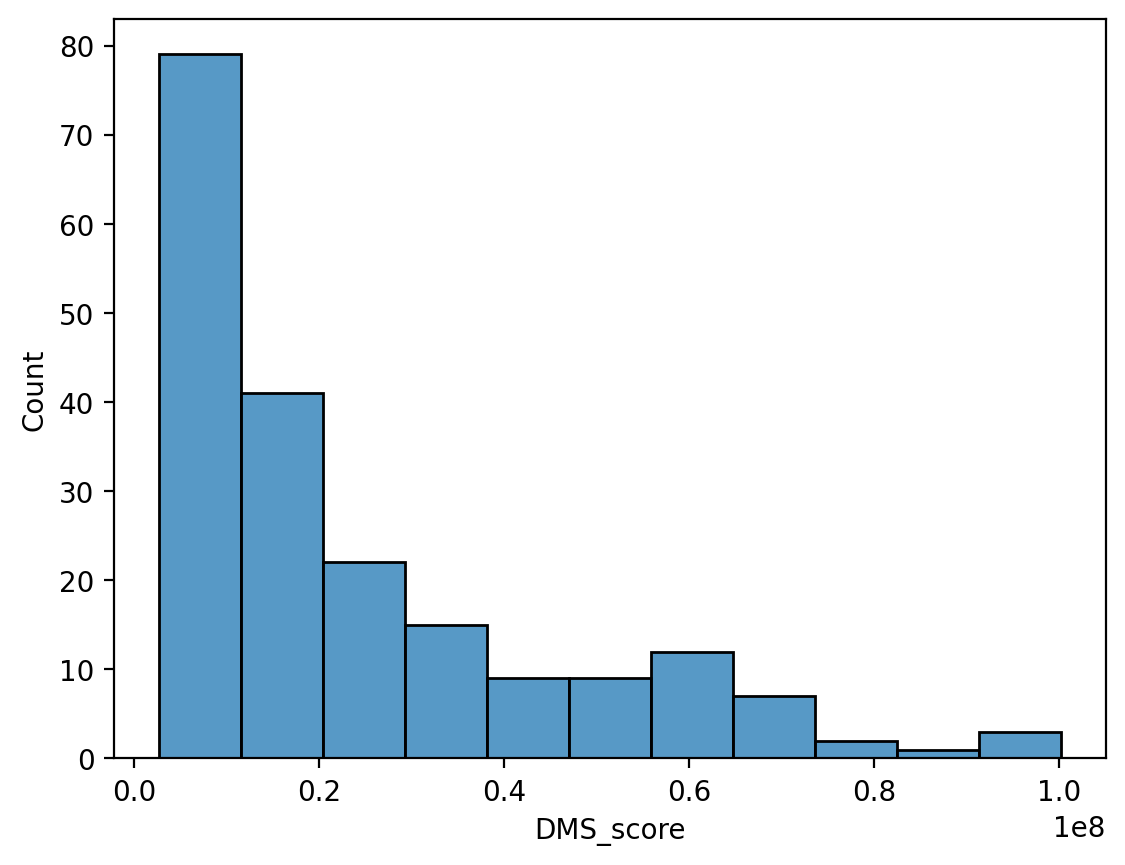

In [20]:
sns.histplot(dfs["B2L11_HUMAN_Dutta_2010_binding-Mcl-1"], x='DMS_score')

### How many DMS assays have enough synonymous mutations for fitting a model?

,DMS_id,DMS_total_number_mutants,num_synon,num_nonsense
94,PAI1_HUMAN_Huttinger_2021,5345,379,0
95,HXK4_HUMAN_Gersing_2023_abundance,8396,379,426
96,PHOT_CHLRE_Chen_2023,167529,2,63
97,S22A1_HUMAN_Yee_2023_abundance,9803,523,0
98,S22A1_HUMAN_Yee_2023_activity,10094,523,0
...,...,...,...,...
212,GLPA_HUMAN_Elazar_2016,245,15,0
213,LYAM1_HUMAN_Elazar_2016,359,23,0
214,GDIA_HUMAN_Silverstein_2021,1154,0,0
215,PPARG_HUMAN_Majithia_2016,9576,0,0


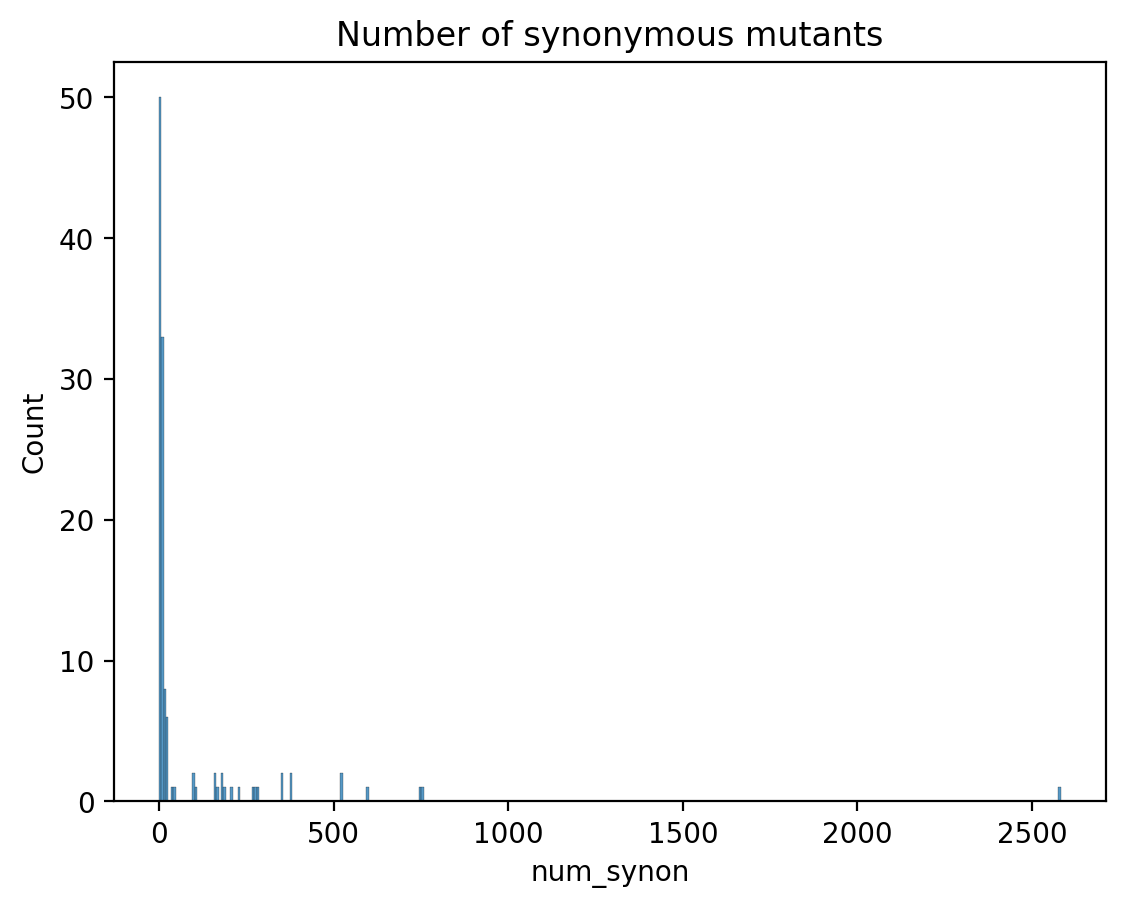

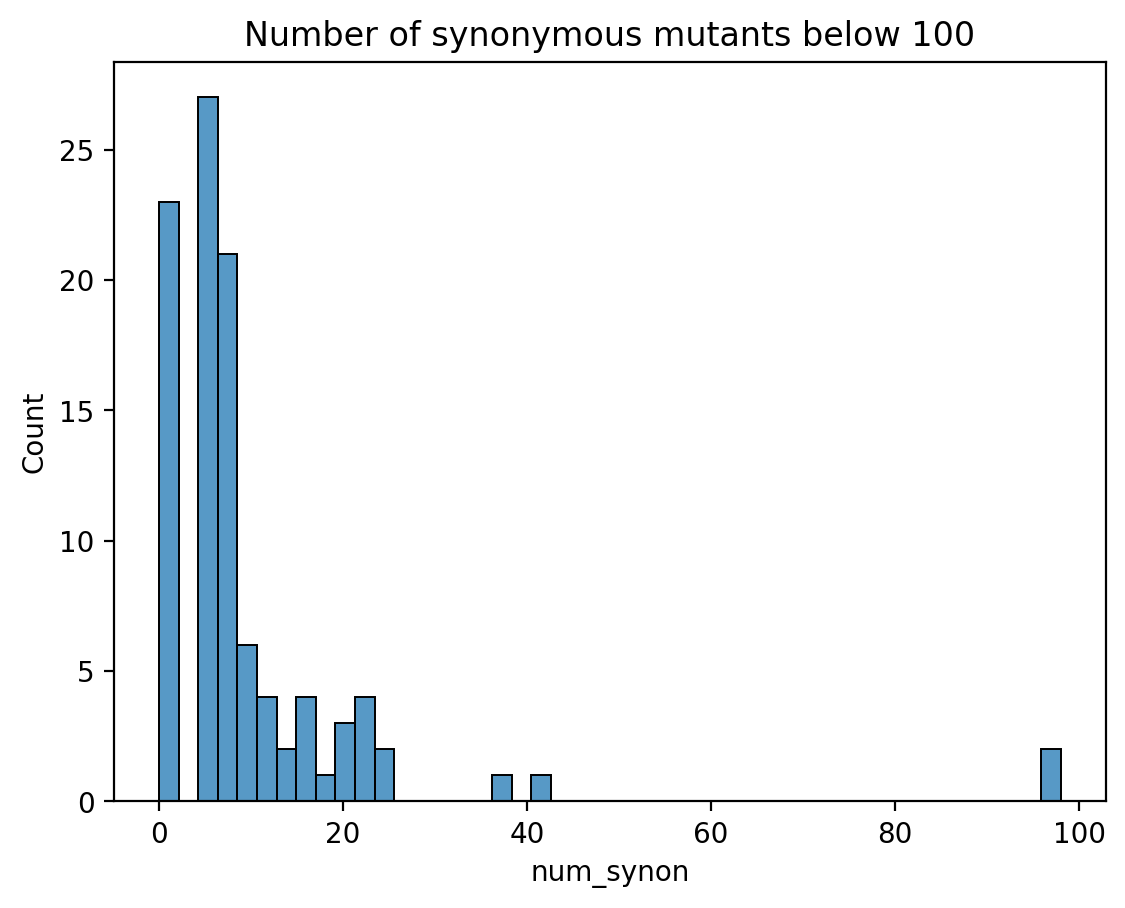

Number of datasets with nonsense mutants: 22


In [21]:
display(df_new[["DMS_id", "DMS_total_number_mutants", "num_synon", "num_nonsense"]])
sns.histplot(df_new, x='num_synon')
plt.title("Number of synonymous mutants")
plt.show()
sns.histplot(df_new[df_new["num_synon"] < 100], x='num_synon')
plt.title("Number of synonymous mutants below 100")
plt.show()

print("Number of datasets with nonsense mutants:", (df_new["num_nonsense"] != 0).sum()) # 25 datasets have some nonsense mutants

In [22]:
df_new[df_new["DMS_id"].str.contains("Rocklin")]["num_nonsense"].value_counts()  # All zero nonsense

0    64
Name: num_nonsense, dtype: int64

In [23]:
rocklin_example = dfs["YAIA_ECOLI_Rocklin_2023_2KVT"]  # Lil Jon "yeeah" sound
display(rocklin_example.head())
display(rocklin_example["mut_class"].value_counts())

# Check whether multiples have wt
rocklin_example[rocklin_example["mut_class"] == "multiple"]["mutant"].str.contains("wt").any()

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mutant,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,DMS_score,dG_ML_float,library,mut_class,aa_seq_full_len,pre_post_aa,domain_length,mutation_class
0,2KVT.pdb,TCCGCTGGTGGCTCCGCGGGTGGTTCCGCGGGTGGTTCCGCTCCAC...,1.392917,1.437663,1.346440,0.091223,0.102540,-1.081662,3.350046,3.415356,3.282787,0.132569,0.538346,0.559470,0.512477,0.046993,0.091997,-2.504597,4.083710,4.112982,4.047931,0.065051,4.014514,4.082306,3.936038,0.146268,SAGGSAGGSAGGSAPREAYIVTIEKGKPGQTVTWYQLRADHPKPDS...,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,wt,2KVT.pdb,58,1.3929168629423123,0.5383456002305114,4.014514,-0.151686,False,NaN,-0.151686,4.014514,natural,wt,80,SAGGSAGGSAGGSA-SAGGSAGGSAGGSA,52,synonymous
1,2KVT.pdb_wth,TCCGCTGGCGGCTCTGCGGGCGGTTCTGCTCCGCGTGAAGCGTACA...,1.653917,1.710485,1.607102,0.103382,0.110334,-1.074568,3.731993,3.821242,3.659580,0.161662,0.631113,0.653747,0.591374,0.062373,0.075054,-2.508749,4.218215,4.249852,4.162841,0.087010,4.223678,4.281951,4.175861,0.106090,SAGGSAGGSAPREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISE...,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,wt,2KVT.pdb,58,1.6539167281958798,0.6311131063234381,4.223678,0.057477,False,NaN,0.057477,4.223678,natural,wt,72,SAGGSAGGSA-SAGGSAGGSA,52,synonymous
2,2KVT.pdb_wty,TCCGCGGGTGGCTCTGCGGGCGGTTCTGCGCCACGTGAAGCGTACA...,1.644387,1.699238,1.604796,0.094442,0.089397,-1.074568,3.717154,3.803330,3.656043,0.147287,0.602835,0.632429,0.558010,0.074419,0.069096,-2.508749,4.178789,4.220052,4.116508,0.103544,4.160062,4.208421,4.100432,0.107989,SAGGSAGGSAPREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISE...,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,wt,2KVT.pdb,58,1.644387325576509,0.6028348907219218,4.160062,-0.006139,False,NaN,-0.006139,4.160062,natural,wt,72,SAGGSAGGSA-SAGGSAGGSA,52,synonymous
3,2KVT.pdb_wtm,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTCCACGTGAAGCGTACA...,1.673687,1.698988,1.627398,0.071590,0.081386,-1.074568,3.762953,3.802933,3.690826,0.112107,0.619711,0.643233,0.569274,0.073959,0.073719,-2.508749,4.202304,4.235146,4.132135,0.103011,4.177980,4.237762,4.120723,0.117039,SAGGSAGGSAPREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISE...,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,wt,2KVT.pdb,58,1.673687155560284,0.6197105350469947,4.177980,0.011779,False,NaN,0.011779,4.177980,natural,wt,72,SAGGSAGGSA-SAGGSAGGSA,52,synonymous
4,2KVT.pdb_wte,TCTGCTGGCGGCTCCGCGGGTGGTTCTGCGCCACGTGAAGCGTACA...,1.616780,1.642738,1.583898,0.058840,0.099348,-1.074568,3.674452,3.714592,3.624113,0.090479,0.550579,0.575182,0.527343,0.047839,0.062542,-2.508749,4.106206,4.140337,4.074034,0.066303,4.086369,4.123138,4.048084,0.075054,SAGGSAGGSAPREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISE...,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,wt,2KVT.pdb,58,1.616779720992758,0.5505790201602606,4.086369,-0.079831,False,NaN,-0.079831,4.086369,natural,wt,72,SAGGSAGGSA-SAGGSAGGSA,52,synonymous


multiple    1090
single       923
wt             5
Name: mut_class, dtype: int64

False

## Plot all DMS files

functions can be reused!

In [24]:
blue="C0"
orange="C1"
green="C2"
red="C3"

def plot_dms(df, dms_id, save_path=None, show=False, normalize=True, **plot_kwargs):
    # TODO add label saying grey line is median
    order = ["missense", "synonymous", "wt", "nonsense"]
    if normalize:
        kwargs = {"stat": "percent", "common_norm": False}
    else:
        kwargs = {"stat": "count", "common_norm": True}
    
    ax = sns.histplot(df, x="DMS_score", hue="mutation_class", hue_order=[o for o in order if o in df["mutation_class"].unique()], palette={"missense": blue, "synonymous": green, "wt": orange, "nonsense": red}, **kwargs, **plot_kwargs)
    
    # Option 2: First plot missense on its own, with less transparency, then the others
    # sns.histplot(df[df["mutation_class"] == "missense"], x="DMS_score", hue="mutation_class", hue_order=["missense", "synonymous", "nonsense", "wt"], stat='percent', alpha=0.8, bins=100)
    # sns.histplot(df[df["mutation_class"] != "missense"], x="DMS_score", hue="mutation_class", hue_order=["missense", "synonymous", "nonsense", "wt"], stat='percent', common_norm=False, alpha=0.3, bins=100)
    
    # Plot median line; dashed line black
    plt.axvline(df["DMS_score"].median(), color="black", linestyle="--")

    title = f"{dms_id}"
    if normalize:
        title = f"{dms_id},\nnormalizing classes separately"
    
    # Plot manual cutoff if it exists
    row = df_new[df_new['DMS_id'] == dms_id].iloc[0]
    if row['DMS_binarization_method'] != "median" and not pd.isna(row['DMS_binarization_cutoff']):
        # print(f"Current manual cutoff: {row['DMS_binarization_cutoff']}")
        # print(f"Method: {row['DMS_binarization_method']}")
        directionality = float(row['raw_DMS_directionality'])
        if directionality == -1:
            cutoff_flipped = row['DMS_binarization_cutoff'] * directionality
        else:
            cutoff_flipped = row['DMS_binarization_cutoff']

        plt.axvline(cutoff_flipped, color="red", linestyle="--")
        title += f", \n'{row['DMS_binarization_method']}' cutoff in red={cutoff_flipped:.3g}"
        
        if directionality == -1:
            title += " (flipped)"
    if row.ProteinGym_version not in ["0.1","1"]:
        title += f" version ({row.ProteinGym_version})"
    
    plt.title(title)

    
    if save_path is not None:
        plt.savefig(save_path, dpi=300)
    if show:
        plt.show()
    plt.close()



##############################################################################
overwrite = False
normalized = False

if not overwrite:
    print("Note: Not overwriting existing plots - use overwrite=True to do so, e.g. if you've made changes to plotting")
else:
    print("Overwriting existing plots")

# dms_example = "DYR_ECOLI_Nguyen_2023"  # "DYR_ECOLI_Nguyen_2023"
# plot_dms(dfs[dms_example], dms_example, show=True, normalize=True, bins=100)

pbar = tqdm(dfs.items())
for dms_id, df in pbar:
    pbar.set_postfix(dms_id=dms_id)
    if normalized:
        save_path = f"{plots_folder}/histograms_normalized/{dms_id}.png"
    else:
        save_path = f"{plots_folder}/histograms_unnormalized/{dms_id}.png"

    if os.path.isfile(save_path) and not overwrite:
        continue
    plot_dms(df, dms_id, save_path=save_path, normalize=normalized)

Note: Not overwriting existing plots - use overwrite=True to do so, e.g. if you've made changes to plotting


  0%|          | 0/123 [00:00<?, ?it/s]

### Interactive plots

In [14]:
# Easy way to iterate through DMS plots
# Create a ipywidget where you can slide through images
import ipywidgets as widgets
from IPython.display import Image, display, clear_output

def show_image(dms_id, normalized=False):
    if normalized:
        save_path = f"{plots_folder}/histograms_normalized/{dms_id}.png"
    else:
        save_path = f"{plots_folder}/histograms_unnormalized/{dms_id}.png"

    display(Image(filename=save_path, retina=True))  # Retina makes the image width and height 2x smaller
    # plt.imshow is slower
    # plt.imshow(plt.imread(save_path))
    # plt.show()

# dropdown = widgets.interactive(show_image, dms_id=dfs.keys())
dfs_list = list(dfs.keys())

# Create the function to be mimicked
def interactive_function(selected_option, normalized=False):
    clear_output(wait=True)  # Clear the output without appending
    print(f'DMS id: "{selected_option}"')
    print(f"Index: {dfs_list.index(selected_option)}")
    print(f"Normalized: {normalized}")
    print(f"Median: {dfs[selected_option]['DMS_score'].median()}")
    row = df_new[df_new['DMS_id'] == selected_option].iloc[0]
    directionality = float(row['raw_DMS_directionality'])
    if directionality == -1:
        print(f"Warning: Flipped DMS directionality! Flipping cutoff (plots are already flipped to match final files). Remember that cutoff is in terms of original file though.")
        cutoff_flipped = row['DMS_binarization_cutoff'] * directionality
    else:
        assert directionality == 1
        cutoff_flipped = row['DMS_binarization_cutoff']
    
    if row['DMS_binarization_method'] != "median" and not pd.isna(row['DMS_binarization_cutoff']):
        print(f"Current manual cutoff using '{row['DMS_binarization_method']}': {cutoff_flipped}")
        percentile_of_manual = stats.percentileofscore(dfs[selected_option]["DMS_score"], cutoff_flipped, nan_policy="omit")
        print(f"Percentile of manual cutoff: {percentile_of_manual:.0f}%")  # TODO store these too
    
    
    show_image(dms_id=selected_option, normalized=normalized)
    print(f'DMS id: "{selected_option}"')  # print again for easy copying


# Create the selection drop-down widget
dropdown = widgets.Dropdown(options=dfs.keys(), description='Select an option')

# Create the button widget
next_icon = "fa-arrow-right"  # Font Awesome icon class
right_button = widgets.Button(description='Next plot', icon=next_icon)
prev_icon = "fa-arrow-left"
left_button = widgets.Button(description='Previous plot', icon=prev_icon)

# Let's rather use arrows for right and left buttons
def iterate_dropdown(button, step=1):
    current_value = dropdown.value
    next_value = list(dfs.keys())[(list(dfs.keys()).index(current_value) + step) % len(dfs.keys())]
    dropdown.value = next_value

right_button.on_click(lambda x: iterate_dropdown(x, step=1))
left_button.on_click(lambda x: iterate_dropdown(x, step=-1))

# Use the interact function to link the dropdown and the interactive function
interactive = widgets.interact(interactive_function, selected_option=dropdown)

# Arrange the buttons horizontally using HBox layout
buttons_box = widgets.HBox([left_button, right_button])

# Display the widgets
display(interactive, buttons_box)

interactive(children=(Dropdown(description='Select an option', options=(), value=None), Checkbox(value=False, …

<function __main__.interactive_function(selected_option, normalized=False)>

### Ideas on criteria:
1) If bimodal, choose crossover - But: Bimodal distribution might be nonsense vs (missense + synon) - this wouldn't be the split we want to measure
2) Try not to include too much of nonsense - some of them may be tolerated, sure, but for many it's a useful proxy for "unfit" / "floor of assay"
3) Many missense mutants will also usually fall below WT for phenotypes closely linked with fitness (but e.g. maybe expression might not be closely linked on its own, and some random mutations are more expressed)

### Comment: Bimodal distribution might be nonsense vs (missense + synon) - this wouldn't be the split we want to measure though right?
Aaron: for large assays (same experiment), the same score may have similar meaning; if everything is all bimodal and the crossover point shifts across assays, use the automatic binarization; if it's all the same, can just use the same binarization threshold

In [19]:
# Note: keep these thresholds in flipped mode and unflip later?
thresholds_manual = {
    "HXK4_HUMAN_Gersing_2023_abundance": 0.6,  # Better balance between nonsense and synon
    "S22A1_HUMAN_Yee_2023_abundance": -1,  # Choose a cutoff percentile of synonymous mutations
    # "S22A1_HUMAN_Yee_2023_activity": -1,  # Choosing lower percentile of synonymous mutations; currently in the middle of synonymous; equal to existing manual cutoff   
    # "KCNE1_HUMAN_Muhammad_2023_expression": 0.75,  # Choose a cutoff percentile of synonymous mutations; same as before
    # "KCNE1_HUMAN_Muhammad_2023_function": 0.75,  # Choose a cutoff percentile of synonymous mutations
    "OXDA_RHOTO_Vanella_2023_activity": -0.2,  # Crossover of synon and nonsense (conservative on lower end)
    "OXDA_RHOTO_Vanella_2023_expression": -0.2,
    "F7YBW7_MESOW_Ding_2023": 0.3,
    "RASK_HUMAN_Weng_2022_binding-SOS1": -0.5,  # The median is too close to the nonsense
    "AICDA_HUMAN_Gajula_2014_1cycle": 1,
    "AICDA_HUMAN_Gajula_2014_2cycles": 1, 
    "AICDA_HUMAN_Gajula_2014_3cycles": 1, 
    "CSN4_MOUSE_Rocklin_2023_1UFM": -0.7, # A bit closer to the notch in bimodal distribution
    "HECD1_HUMAN_Rocklin_2023_3DKM": -0.7, # A bit closer to the notch in bimodal distribution
    "ILF3_HUMAN_Rocklin_2023_2L33": -0.4, # Including the whole mode around synonymous
    "MAFG_MOUSE_Rocklin_2023_1K1V": -0.5,
    "MYO3_YEAST_Rocklin_2023_2BTT": -1,
    "NKX31_HUMAN_Rocklin_2023_2L9R": -0.3, # Closer to bimodal crossover
    "NUSG_MYCTU_Rocklin_2023_2MI6": -0.5, 
    "OBSCN_HUMAN_Rocklin_2023_1V1C": -1,
    "OTU7A_HUMAN_Rocklin_2023_2L2D": -1, 
    "PKN1_HUMAN_Rocklin_2023_1URF": -0.5, # Trying to more clearly separate synon
    "POLG_PESV_Rocklin_2023_2MXD": -1.7,
    "RL20_AQUAE_Rocklin_2023_1GYZ": -0.7,
    "PSAE_SYNP2_Rocklin_2023_1PSE": -0.7,
    "SDA_BACSU_Rocklin_2023_1PV0": -1,  # Possibly trimodal; choosing fit (wt replicates) set to be safe?
    "TCRG1_MOUSE_Rocklin_2023_1E0L": -1.2, # Cleaner separation between modes
    "THO1_YEAST_Rocklin_2023_2WQG": -0.7, # Cleaner separation between modes
    "UBE4B_HUMAN_Rocklin_2023_3L1X": -1, # Cleaner separation between modes
    "VILI_CHICK_Rocklin_2023_1YU5": -0.7,
    "VRPI_BPT7_Rocklin_2023_2WNM": -1.1,
    "YNZC_BACSU_Rocklin_2023_2JVD": -1, # Cleaner separation between modes
    "SOX2_MOUSE_Veerapandian_2018": -1, # Aaron: If score is log-fold induction or something
    "RPC1_LAMBD_Li_2019_high-expression": 7, # Note: Flipped directionality, this is the binary cutoff on the plot
}
manual_thresholds_fine = [
    'S22A1_HUMAN_Yee_2023_activity', 'KCNE1_HUMAN_Muhammad_2023_expression', 'KCNE1_HUMAN_Muhammad_2023_function'
    "RNC_ECOLI_Weeks_2023",
    "PRKN_HUMAN_Clausen_2023",  # Not much difference either way
    "DYR_ECOLI_Nguyen_2023", # Very interesting that synon are all ~equal - might be data issue or assay not sensitive to codons / technical noise
    "PRKN_HUMAN_Clausen_2023",  # Good balance between "far away from nonsense" and "still close to median"
    "ENVZ_ECOLI_Ghose_2023",
]
use_median = [  # Overriding manual cutoffs, check with reviewers
    "OXDA_RHOTO_Vanella_2023_expression", # Actually even though synon goes far to the left, overall distribution looks unimodal and median is fine?
    "OXDA_RHOTO_Vanella_2023_activity", # Median fine even when checking manually
    "SRC_HUMAN_Nguyen_2022",
    "RASK_HUMAN_Weng_2022_abundance",
    "RASK_HUMAN_Weng_2022_binding-RAF1",
    "RASK_HUMAN_Weng_2022_binding-PIK3CG",
    "RASK_HUMAN_Weng_2022_binding-RALGDS",
    "RASK_HUMAN_Weng_2022_binding-DARPin_K55",
    "RASK_HUMAN_Weng_2022_binding-DARPin_K27",
    "SRC_HUMAN_Chakraborty_2023_binding-inhibitor_1",
    "SRC_HUMAN_Chakraborty_2023_binding-inhibitor_2", # I guess it's fine, a higher score would've been a bit more desirable to avoid nonsense  
]

# Default median fine:
# "B2L11_HUMAN_Dutta_2010_binding-Mcl-1",
# "Q53Z42_HUMAN_McShan_2019_expression",
# "Q53Z42_HUMAN_McShan_2019_binding-TAPBPR",
# RPC1_LAMBD_Li_2019_low-expression


# Comments: 
# Q837P4_ENTFA_Meier_2023: The median looks like a decent cutoff between synon and (missense + nonsense), instead of a cutoff between (synon + missense) vs nonsense
# AICDA_HUMAN_Gajula_2014_2cycles: I only see missense, no stop or wt. Would be useful to add them back in if possible. Also weird exponential distribution
# Similar distributions: PKN1_HUMAN_Rocklin_2023_1URF & RS15_GEOSE_Rocklin_2023_1A32
# Rocklin looking trimodal: RCRO_LAMBD_Rocklin_2023_1ORC 

problems = [
    "OXDA_RHOTO_Vanella_2023_expression",  # This -1 seems way off!
    "OXDA_RHOTO_Vanella_2023_activity",  # This -0.75 seems way off!
    # "RASK_HUMAN_Weng_2022_abundance", # This 1.12 seems way off!  # Ada's redone the RASK GMM thresholds
]

flagged = [
    "CCR5_HUMAN_Gill_2023",  # Big noise and crossover between synon and nonsense
]

# Old:
# "POLG_DEN26_Suphatrakul_2023": -4,  # Overriding, Aaron said it's better as -3

## August 2023: Stop here and write out values (automatic binarization can be added later)

In [26]:
# Update df_new with thresholds_manual and use_median
manual_df_new = pd.DataFrame(thresholds_manual, columns=["DMS_id", "DMS_binarization_cutoff_new"])
for dms_id, threshold in thresholds_manual.items():
    df_new.loc[df_new["DMS_id"] == dms_id, "DMS_binarization_cutoff_new"] = threshold
    df_new.loc[df_new["DMS_id"] == dms_id, "DMS_binarization_method_new"] = "manual_Lood"

# Keep some of the manual thresholds:
df_new.loc[df_new["DMS_id"].isin(manual_thresholds_fine), "DMS_binarization_method_new"] = "manual"
df_new.loc[df_new["DMS_id"].isin(manual_thresholds_fine), "DMS_binarization_cutoff_new"] = df_new.loc[df_new["DMS_id"].isin(manual_thresholds_fine)]["DMS_binarization_cutoff"] * df_new.loc[df_new["DMS_id"].isin(manual_thresholds_fine)]["raw_DMS_directionality"].astype(float)

# For the rest keep median:
# pass: This is done automatically
assert df_new["DMS_binarization_cutoff_new"].isna().sum() == 0

df_new[df_new["DMS_id"] == "POLG_DEN26_Suphatrakul_2023"]

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,DMS_number_multiple_mutants,DMS_binarization_cutoff,DMS_binarization_method,first_author,title,year,jo,region_mutated,molecule_name,selection_assay,selection_type,library_construction,replicates,MSA_filename,MSA_start,MSA_end,MSA_len,MSA_bitscore,MSA_theta,MSA_num_seqs,MSA_perc_cov,MSA_num_cov,MSA_N_eff,MSA_Neff_L,MSA_Neff_L_category,MSA_num_significant,MSA_num_significant_L,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,reviewed_by,Comments,Old_DMS_ID,Old_UniProt_ID,Old_target_seq,MSA_comments,ProteinGym_version,Reason excluded,raw_mut_offset,num_synon,num_nonsense,DMS_binarization_cutoff_new,DMS_binarization_method_new
299,POLG_DEN26_Suphatrakul_2023,POLG_DEN26_Suphatrakul_2023.csv,POLG_DEN26,Virus,Dengue virus,GTGNIGETLGEKWKSRLNALGKSEFQIYKKSGIQEVDRTLAKEGIK...,900.0,FALSE,16897,16897,0.0,-5.373371,median,Suphatrakul,Functional analysis of flavivirus replicase by...,2023,10.1101/2023.03.07.531617,2492-3391,Flavivirus NS5,Viral replication,Growth,Oligo pool synthesis,3 biological replicates,POLG_DEN26_2023-08-07_b01.a2m,1.0,900.0,900.0,0.1,0.01,10676.0,1.0,900.0,114.5,0.127222,Low,0.0,0.0,POLG_DEN26_Suphatrakul_2023.csv,score,1,mutant,POLG_DEN26_theta0.01_2023-08-07_b01.npy,Aaron,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0,0,-5.373371,median


In [22]:
# df_new.to_csv(mapping_file_with_thresholds, index=False)

# Merge with mapping file
shared_cols = [c for c in df_new.columns if c in df_ref.columns]
df_merged = df_ref.merge(df_new, on=shared_cols, how='outer')  # Only DMS_binarization_cutoff_new and DMS_binarization_method_new are new
assert len(df_merged) == len(df_ref)
print(set(df_merged.columns) - set(df_ref.columns))
# Write out
df_merged.to_csv(mapping_file_with_thresholds, index=False)

{'DMS_binarization_method_new', 'num_nonsense', 'DMS_binarization_cutoff_new', 'num_synon'}


## Bimodality test

To-do for PG2! Need to google

## Approach 1: GMM

In [208]:
gmm = GaussianMixture(n_components=2, random_state=0)
df_example = dfs["HXK4_HUMAN_Gersing_2023_abundance"]
gmm.fit(df_example["DMS_score"].values.reshape(-1, 1))

GaussianMixture(n_components=2, random_state=0)

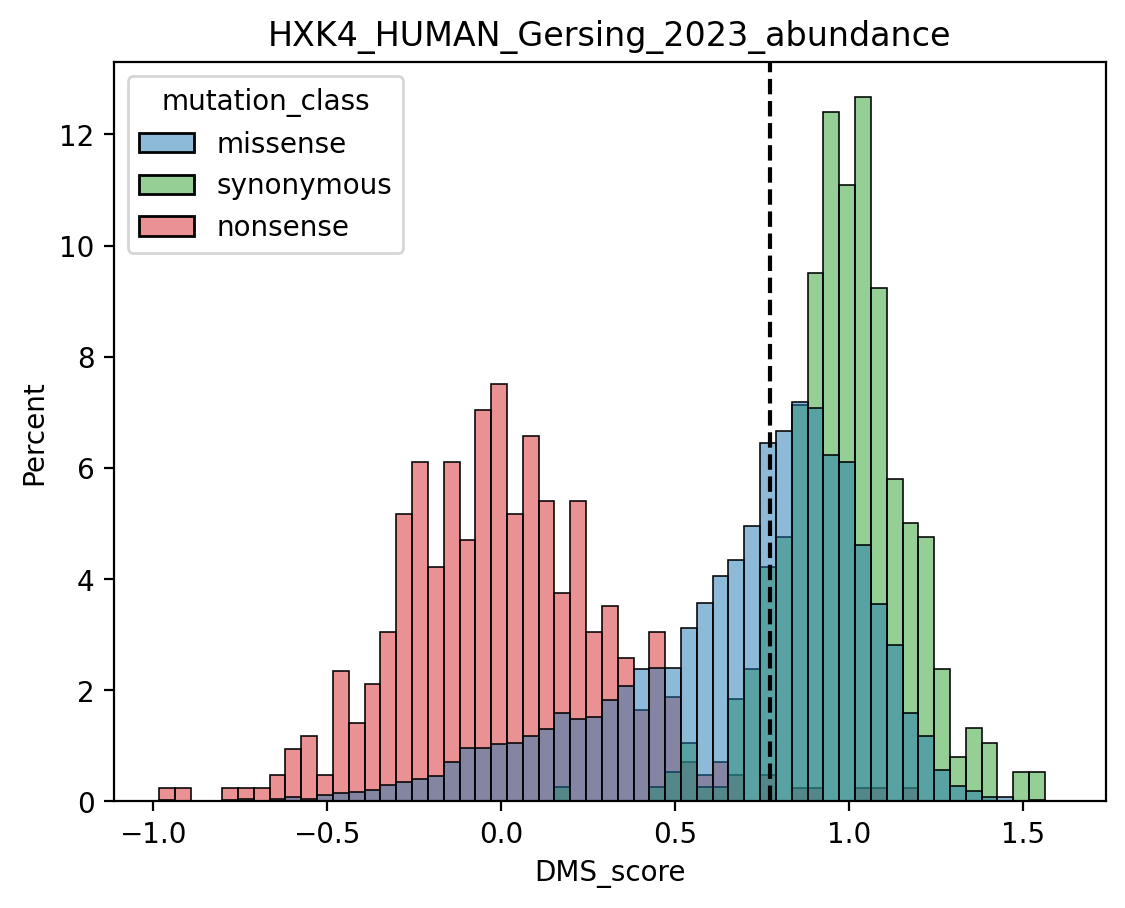

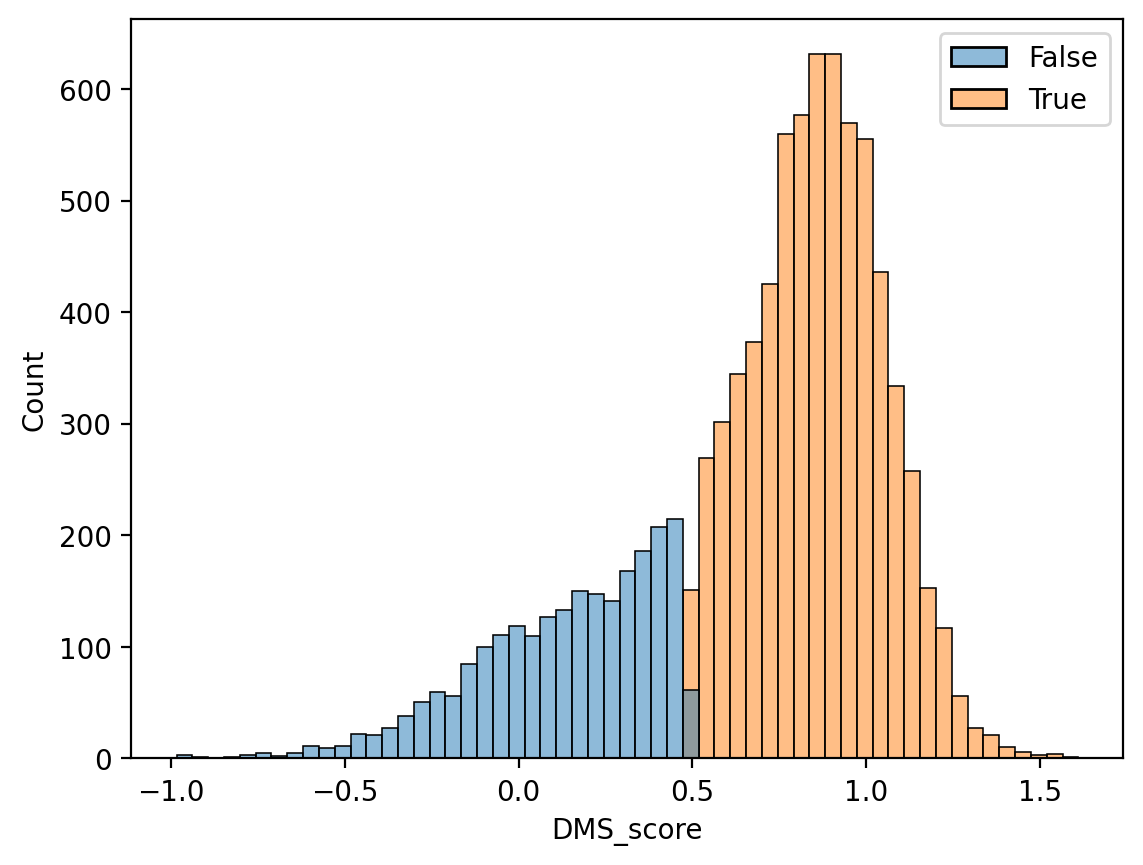

In [245]:
plot_dms(df_example, "HXK4_HUMAN_Gersing_2023_abundance", show=True, normalize=True)
probs = gmm.predict_proba(df_example["DMS_score"].values.reshape(-1, 1))
sns.histplot(df_example, x="DMS_score", hue=(probs[:,0] > 0.5))  # Note: Should we even use 0.5 or just the midpoint of densities? To minimize error
plt.show()

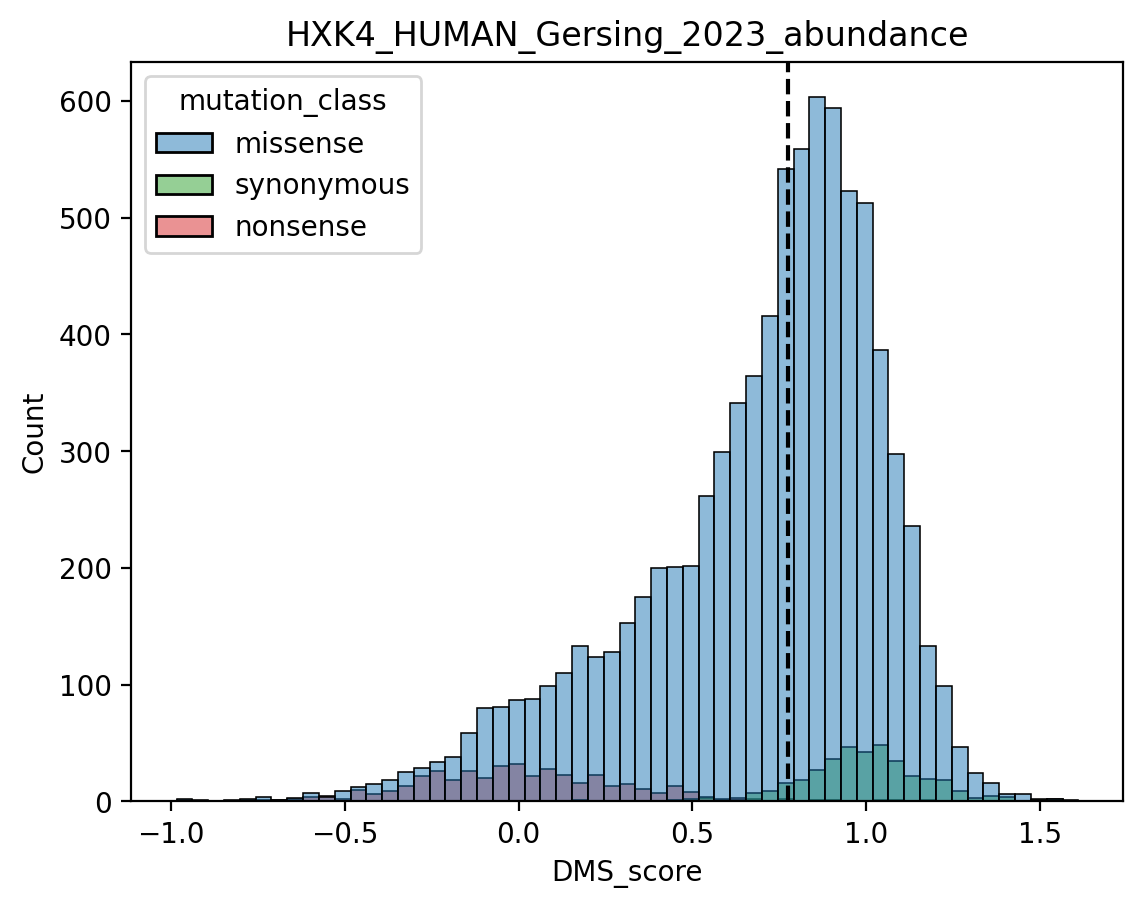

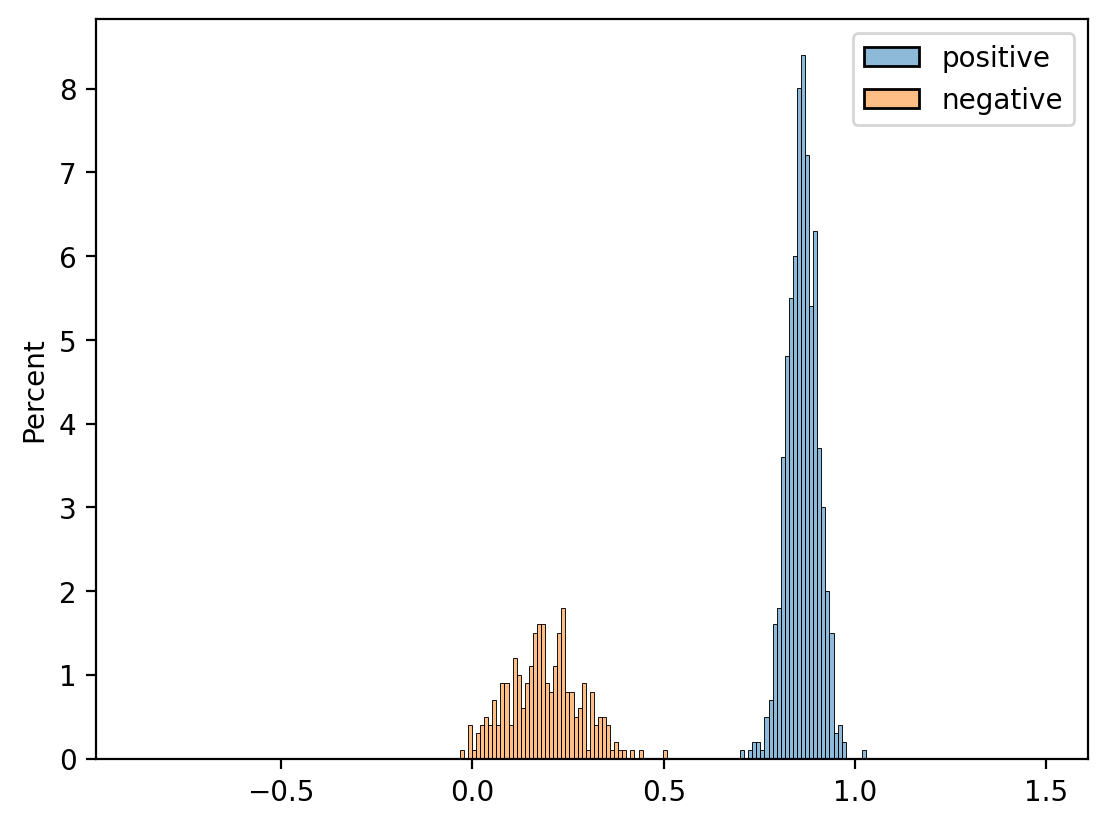

In [237]:
# Sample from the densities using sklearn / scipy normal
from scipy.stats import norm
# Positive:
pos = norm(loc=gmm.means_[0, 0], scale=gmm.covariances_[0, 0]).rvs(int(1000 * gmm.weights_[0]))  # More samples from the higher weighted one
neg = norm(loc=gmm.means_[1, 0], scale=gmm.covariances_[1, 0]).rvs(int(1000 * gmm.weights_[1]))

plot_dms(df_example, "HXK4_HUMAN_Gersing_2023_abundance", show=True, normalize=False)
concat_array = np.concatenate([pos, neg])
labels = ["positive"] * int(1000 * gmm.weights_[0]) + ["negative"] * int(1000 * gmm.weights_[1])
sns.histplot(x=concat_array, hue=labels, stat='percent', bins=100)
# Add xmin and xmax to match the DMS_score plot
xmin, xmax = df_example["DMS_score"].min(), df_example["DMS_score"].max()
plt.xlim(xmin, xmax)
plt.show()


# TODO figure out what threshold should be 
# - Either the overlap point between the densities, or the threshold that balances both Types I and II errors

## 3-component gmm

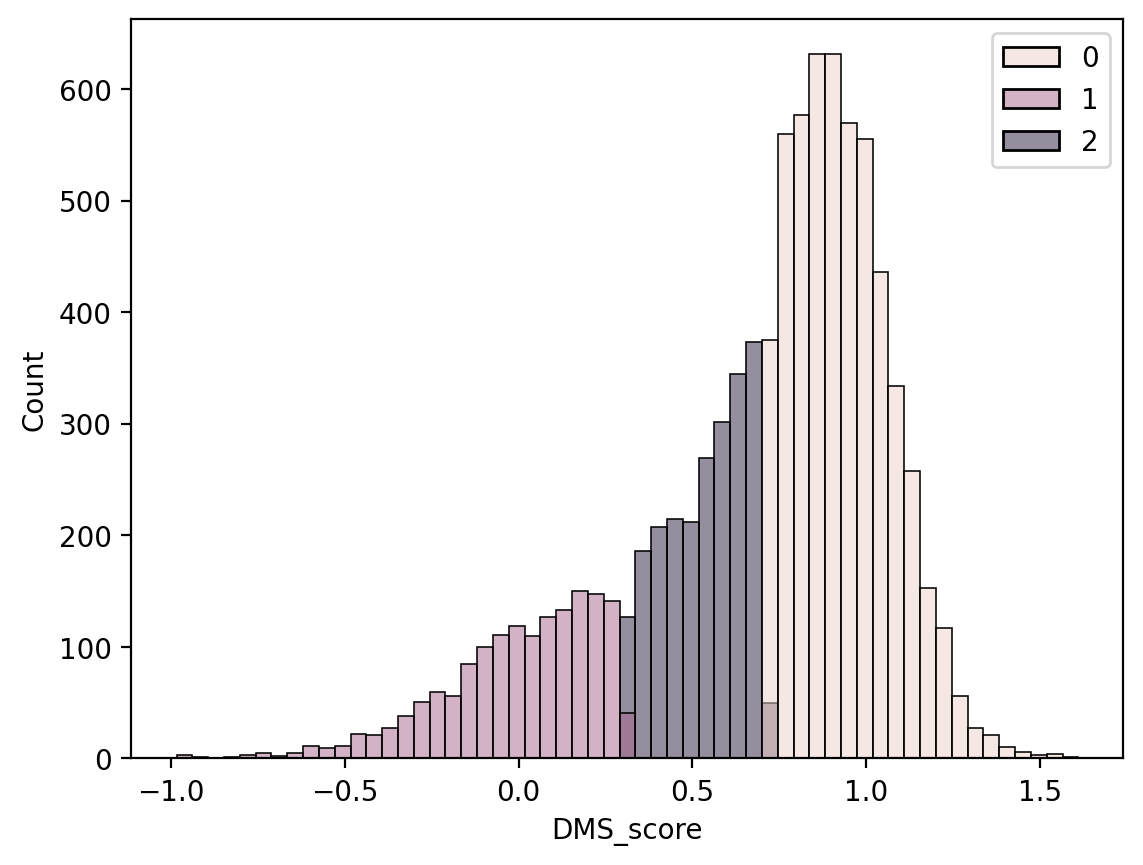

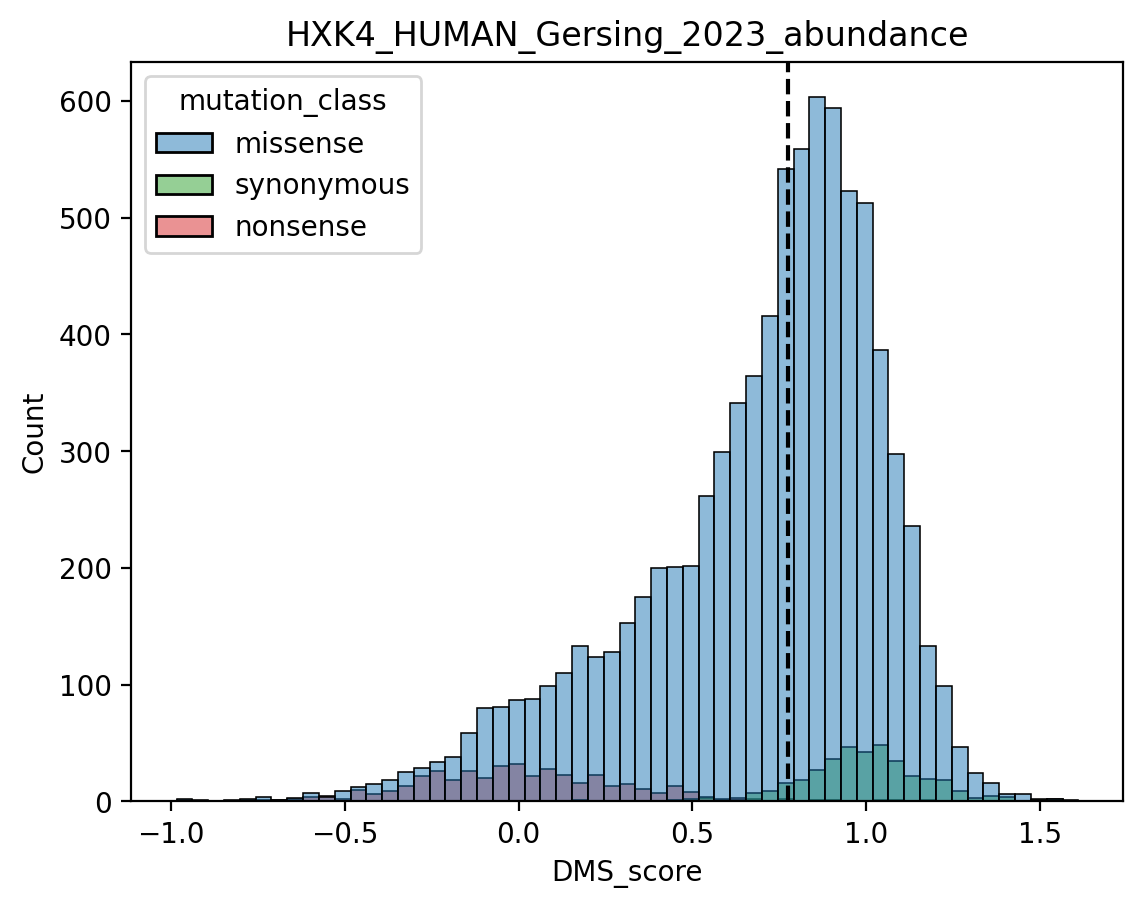

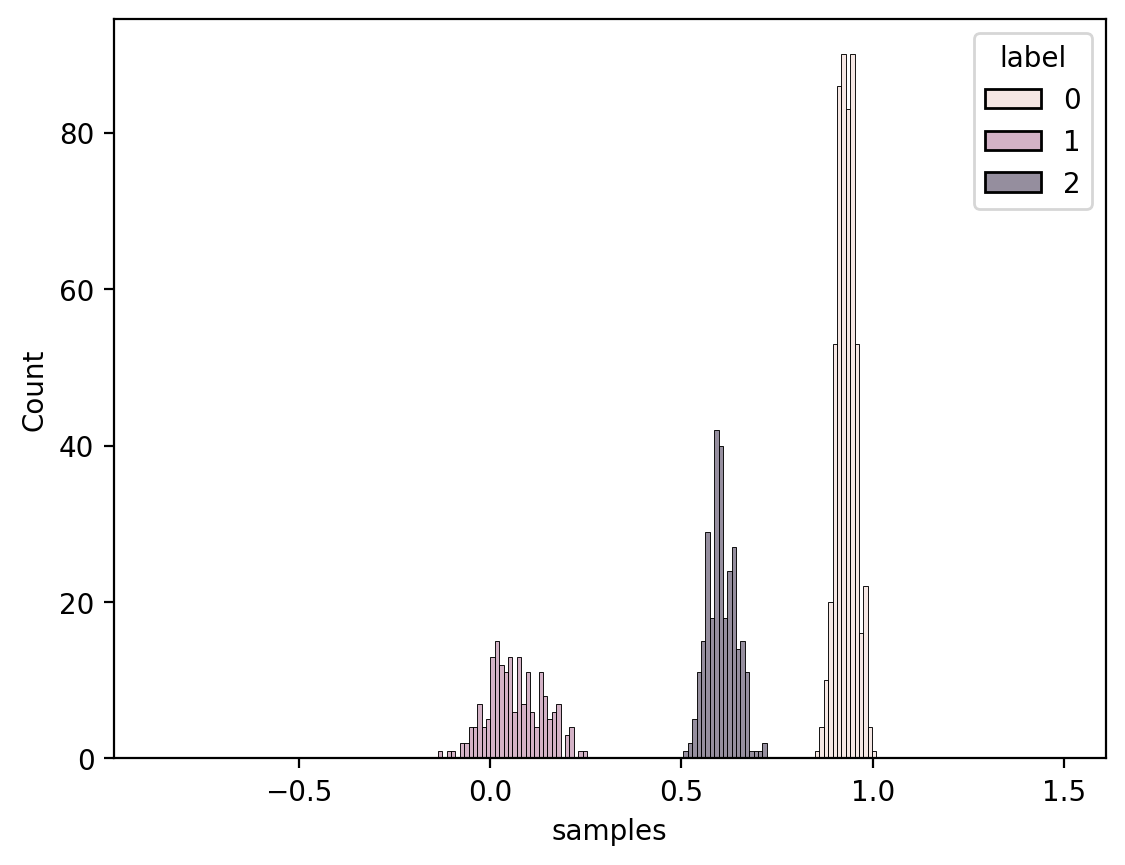

In [248]:
gmm3 = GaussianMixture(n_components=3, random_state=0)
gmm3.fit(df_example["DMS_score"].values.reshape(-1, 1))
preds = gmm3.predict(df_example["DMS_score"].values.reshape(-1, 1))

sns.histplot(df_example, x="DMS_score", hue=preds)
plt.show()

# Plot GMM densities
samples = [None, None, None]
for i in range(3):
    samples[i] = norm(loc=gmm3.means_[i, 0], scale=gmm3.covariances_[i, 0]).rvs(int(1000 * gmm3.weights_[i]))

# Flatten out the samples
concat_array = np.concatenate(samples)
#["positive"] * int(1000 * gmm.weights_[0]) + ["negative"] * int(1000 * gmm.weights_[1])
labels = [0] * int(1000 * gmm3.weights_[0]) + [1] * int(1000 * gmm3.weights_[1]) + [2] * int(1000 * gmm3.weights_[2])

df_samples = pd.DataFrame({"samples": concat_array, "label": labels})

plot_dms(df_example, "HXK4_HUMAN_Gersing_2023_abundance", show=True, normalize=False)
plt.show()

sns.histplot(df_samples, x="samples", bins=100, hue=df_samples["label"])
plt.xlim(xmin, xmax)
plt.show()